In [62]:
print("Test")

Test


In [100]:
import os
print(bool(os.getenv("GROQ_API_KEY")))

True


In [81]:
#Imports

from langchain_groq import ChatGroq
from langchain_core.tools import tool

from langchain_core.messages import (
    HumanMessage,
    SystemMessage,
    AIMessage,
    ToolMessage
)

from langgraph.graph import(
    StateGraph,
    MessagesState,
    START,
    END
)
from langgraph.prebuilt import (
    ToolNode,
    tools_condition
)

## Creating Different Tools which will be called by LLM

In [82]:
# Creating 5 Different Tools

@tool
def add (a:float, b:float)-> float:
    """Use this Tool when ever there is need to Add Two Numbers"""
    return a+b

@tool
def Subtract(a:float,b:float)->float:
    """Use this Tool When ever there is need to Substract Two Numbers"""
    return a-b

@tool
def Multiply(a:float,b:float)->float:
    """This tool is used Whenever there is need to Multiply Two Numbers"""
    return a*b

@tool
def divide(a: float, b: float) -> float:
    """
    Divide a by b.
    Use this tool whenever division is required.
    """

    if b == 0:
        raise ValueError(
            "Division by zero is not allowed."
        )

    return a / b


@tool
def power(base: float, exponent: float) -> float:
    """
    Raise a number to a power.
    """

    return base ** exponent


## ToolList

In [83]:
tools=[add,Subtract,Multiply,divide,power]

In [84]:
tools

[StructuredTool(name='add', description='Use this Tool when ever there is need to Add Two Numbers', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x0000020F717C2520>),
 StructuredTool(name='Subtract', description='Use this Tool When ever there is need to Substract Two Numbers', args_schema=<class 'langchain_core.utils.pydantic.Subtract'>, func=<function Subtract at 0x0000020F717C34C0>),
 StructuredTool(name='Multiply', description='This tool is used Whenever there is need to Multiply Two Numbers', args_schema=<class 'langchain_core.utils.pydantic.Multiply'>, func=<function Multiply at 0x0000020F717C3D80>),
 StructuredTool(name='divide', description='Divide a by b.\nUse this tool whenever division is required.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x0000020F717C2660>),
 StructuredTool(name='power', description='Raise a number to a power.', args_schema=<class 'langchain_core.utils.pydantic.power'>, func=<fu

In [85]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)

## Bind LLM With Tools

In [86]:
llm_with_tools=llm.bind_tools(tools)

## System Prompt

In [87]:
SYSTEM_PROMPT = """

You are a mathematical agent.

You have access to five tools:

1. add
2. Multiply
3. subtract
4. divide
5. power

Important rules:

- Use tools for mathematical calculations.
- Follow the user's requested calculation order.
- When one operation depends on the previous result,
  wait for that tool result before calling the next tool.
- Do not perform calculations yourself; always use the appropriate tool
- Use exactly the appropriate tool for each operation.
- After all required tool calls are complete,
  provide the final answer.

"""

***Why state["messages"] is passed to messages in llm_node?***

- LangGraph nodes are stateless functions. The LLM is also stateless: every call starts with no memory. So the node has to hand the model the whole conversation each time, and state["messages"] is where that conversation is kept.

In [90]:
# Agent Node

def llm_node(state:MessagesState):
    messages=[SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response=llm_with_tools.invoke(messages)
    return {"messages":[response]}

In [91]:
tool_node=ToolNode(tools)

**ToolNode**

- ToolNode is a ready-made LangGraph node that runs the tools the LLM asked for.
- The LLM never runs code itself. It only returns a request like "call get_weather with {city: 'Hyderabad'}", and ToolNode does the   actual call.

## Add Nodes And Edges

In [92]:
# Create Graph

workflow=StateGraph(MessagesState)

In [93]:
workflow.add_node("llm_node",llm_node)
workflow.add_node("tools",tool_node)

In [94]:
workflow.add_edge(START,"llm_node")

workflow.add_conditional_edges(
    "llm_node",
    tools_condition,
    {
        "tools":"tools",
         END:END
    }
)
workflow.add_edge("tools","llm_node")

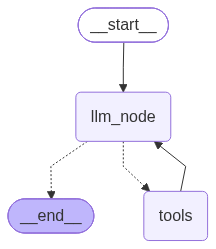

In [95]:
app=workflow.compile()
app

In [96]:
# Test Question

question = """

Perform the following calculation step by step.

1. Add 10 and 20.
2. multiply the result by 3.
3. Subtract 15 from the result.
4. Divide the result by 5.
5. Raise the final result to the power of 2.

You must use the corresponding tool for every step.

"""

In [97]:
result=app.invoke({"messages":[HumanMessage(content=question)]})

print("Final Result:",result)

Final Result: {'messages': [HumanMessage(content='\n\nPerform the following calculation step by step.\n\n1. Add 10 and 20.\n2. multiply the result by 3.\n3. Subtract 15 from the result.\n4. Divide the result by 5.\n5. Raise the final result to the power of 2.\n\nYou must use the corresponding tool for every step.\n\n', additional_kwargs={}, response_metadata={}, id='7db4dafa-9661-4cb3-8b15-79492b6cf0a8'), AIMessage(content='', additional_kwargs={'reasoning_content': "We need to perform step by step, using tools. We must call add, multiply, subtract, divide, power. Each step uses previous result. We must wait for tool result before next. So we need to call add first. Then multiply. Then subtract. Then divide. Then power. Provide final answer. Let's do.\n\nStep1: add 10 and 20. Use add tool.", 'tool_calls': [{'id': 'fc_382cae3c-f73e-47ed-960e-e87396777445', 'function': {'arguments': '{"a":10,"b":20}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_t

In [98]:
for i, message in enumerate(
    result["messages"],
    start=1
):

    print("=" * 70)

    print(
        f"MESSAGE {i}: "
        f"{message.__class__.__name__}"
    )

    print("=" * 70)

    # AI MESSAGE
    if isinstance(
        message,
        AIMessage
    ):

        if message.tool_calls:

            print(
                "TOOL CALLS:"
            )

            for call in message.tool_calls:

                print(
                    "Tool Name:",
                    call["name"]
                )

                print(
                    "Arguments:",
                    call["args"]
                )

        if message.content:

            print(
                "Content:",
                message.content
            )


    # TOOL MESSAGE
    elif isinstance(
        message,
        ToolMessage
    ):

        print(
            "Tool Result:",
            message.content
        )


    # HUMAN MESSAGE
    else:

        print(
            message.content
        )

MESSAGE 1: HumanMessage


Perform the following calculation step by step.

1. Add 10 and 20.
2. multiply the result by 3.
3. Subtract 15 from the result.
4. Divide the result by 5.
5. Raise the final result to the power of 2.

You must use the corresponding tool for every step.


MESSAGE 2: AIMessage
TOOL CALLS:
Tool Name: add
Arguments: {'a': 10, 'b': 20}
MESSAGE 3: ToolMessage
Tool Result: 30.0
MESSAGE 4: AIMessage
TOOL CALLS:
Tool Name: Multiply
Arguments: {'a': 30, 'b': 3}
MESSAGE 5: ToolMessage
Tool Result: 90.0
MESSAGE 6: AIMessage
TOOL CALLS:
Tool Name: Subtract
Arguments: {'a': 90, 'b': 15}
MESSAGE 7: ToolMessage
Tool Result: 75.0
MESSAGE 8: AIMessage
TOOL CALLS:
Tool Name: divide
Arguments: {'a': 75, 'b': 5}
MESSAGE 9: ToolMessage
Tool Result: 15.0
MESSAGE 10: AIMessage
TOOL CALLS:
Tool Name: power
Arguments: {'base': 15, 'exponent': 2}
MESSAGE 11: ToolMessage
Tool Result: 225.0
MESSAGE 12: AIMessage
Content: **Step-by-step calculation:**

1. **Add 10 and 20** → 30  
2. **Mult

In [99]:
# # ============================================================
# # FINAL ANSWER
# # ============================================================

print("\n")
print("=" * 70)
print("FINAL ANSWER")
print("=" * 70)

print(
    result["messages"][-1].content
)



FINAL ANSWER
**Step-by-step calculation:**

1. **Add 10 and 20** → 30  
2. **Multiply the result by 3** → 90  
3. **Subtract 15 from the result** → 75  
4. **Divide the result by 5** → 15  
5. **Raise the final result to the power of 2** → 225  

**Final answer:** 225


## How Above Example works
1. START → llm_node. The LLM reads the system prompt and the full message history, then decides which tool to call and with what arguments. It returns an AIMessage with tool_calls.
2. tools_condition checks the last message. If tool_calls isn't empty, it routes to "tools". If it's empty, it routes to END. It never picks a tool.
3. ToolNode reads each tool name from tool_calls, looks up the matching function, runs it, and adds a ToolMessage with the result to state.
4. tools → llm_node. This edge is unconditional. The LLM now sees the tool result in the history and decides the next step.
5. The loop repeats until the LLM replies with plain text and no tool_calls. Then tools_condition returns END.


***What Actually Happens ***
1. llm_node returns an AIMessage. The tool name and arguments are stored in that message's tool_calls field.
2. LangGraph adds that message to state["messages"].
3. tools_condition reads the last message in state and only asks whether tool_calls is empty. It returns "tools" or END. It ignores the tool name.
4. ToolNode reads the same last message from state. It's the one that uses tool_calls[i]["name"] and ["args"] to find the right function and run it.

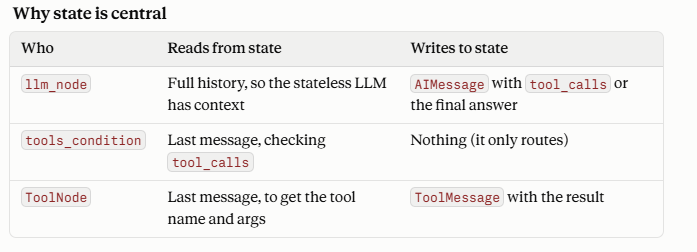

```text
llm_node ──returns──► AIMessage(tool_calls=[{name:"add", args:{a:10,b:20}}])
                             │
                             ▼  (saved into state["messages"])
                      state["messages"][-1]
                        ▲                  ▲
         reads it only  │                  │ reads it and
         to check empty │                  │ runs the tool
                 tools_condition        ToolNode
```text



## Our Next Task is to convert above example more automated using llm itself(Reason) without using conditional edges, how Tools are identified and executed.

- Basically we want to Build ReAct Agent

## ReAct Agent

- Reasoning : LLM To Think 
- Action : Tool Calling